### Libraries

In [1]:
import re
import math
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

random.seed(11)
np.random.seed(11)
torch.manual_seed(11)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


### Load Dataset

In [2]:
DATA_FILE = "/content/sample_data/rus.txt"
MAX_ROWS = 12000

raw_pairs = []

with open(DATA_FILE, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) >= 2:
            en_text = parts[0]
            ru_text = parts[1]
            raw_pairs.append((en_text, ru_text))

data_table = pd.DataFrame(raw_pairs, columns=["en_raw", "ru_raw"])
data_table = data_table.iloc[:MAX_ROWS].copy().reset_index(drop=True)

print(data_table.head())
print("Total rows used:", len(data_table))

  en_raw         ru_raw
0    Go.          Марш!
1    Go.           Иди.
2    Go.         Идите.
3    Hi.  Здравствуйте.
4    Hi.        Привет!
Total rows used: 12000


### Text Cleaning

In [3]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Zа-яА-ЯёЁ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data_table["en_text"] = data_table["en_raw"].apply(normalize_text)
data_table["ru_text"] = data_table["ru_raw"].apply(normalize_text)

data_table = data_table[
    (data_table["en_text"] != "") &
    (data_table["ru_text"] != "")
].copy()

data_table["en_len"] = data_table["en_text"].apply(lambda x: len(x.split()))
data_table["ru_len"] = data_table["ru_text"].apply(lambda x: len(x.split()))

data_table = data_table[
    (data_table["en_len"] >= 1) & (data_table["en_len"] <= 14) &
    (data_table["ru_len"] >= 1) & (data_table["ru_len"] <= 16)
].copy().reset_index(drop=True)

print(data_table[["en_text", "ru_text", "en_len", "ru_len"]].head())
print("Rows after cleaning/filtering:", len(data_table))

  en_text       ru_text  en_len  ru_len
0      go          марш       1       1
1      go           иди       1       1
2      go         идите       1       1
3      hi  здравствуйте       1       1
4      hi        привет       1       1
Rows after cleaning/filtering: 12000


### Add Special Tokens and Tokenize

In [4]:
data_table["ru_text"] = data_table["ru_text"].apply(lambda x: "<sos> " + x + " <eos>")

data_table["en_tokens"] = data_table["en_text"].apply(lambda x: x.split())
data_table["ru_tokens"] = data_table["ru_text"].apply(lambda x: x.split())

print(data_table[["en_tokens", "ru_tokens"]].head())

  en_tokens                     ru_tokens
0      [go]          [<sos>, марш, <eos>]
1      [go]           [<sos>, иди, <eos>]
2      [go]         [<sos>, идите, <eos>]
3      [hi]  [<sos>, здравствуйте, <eos>]
4      [hi]        [<sos>, привет, <eos>]


### Build Vocabularies

In [5]:
SPECIAL_TOKENS = ["<pad>", "<unk>", "<sos>", "<eos>"]

def make_vocab(token_series):
    vocab = {tok: idx for idx, tok in enumerate(SPECIAL_TOKENS)}
    for sent in token_series:
        for token in sent:
            if token not in vocab:
                vocab[token] = len(vocab)
    return vocab

src_vocab = make_vocab(data_table["en_tokens"])
tgt_vocab = make_vocab(data_table["ru_tokens"])

src_id2word = {idx: word for word, idx in src_vocab.items()}
tgt_id2word = {idx: word for word, idx in tgt_vocab.items()}

print("English vocab size:", len(src_vocab))
print("Russian vocab size:", len(tgt_vocab))

English vocab size: 1958
Russian vocab size: 5261


In [6]:
def tokens_to_ids(tokens, vocab):
    return [vocab.get(tok, vocab["<unk>"]) for tok in tokens]

data_table["en_ids"] = data_table["en_tokens"].apply(lambda x: tokens_to_ids(x, src_vocab))
data_table["ru_ids"] = data_table["ru_tokens"].apply(lambda x: tokens_to_ids(x, tgt_vocab))

print(data_table[["en_ids", "ru_ids"]].head())

  en_ids     ru_ids
0    [4]  [2, 4, 3]
1    [4]  [2, 5, 3]
2    [4]  [2, 6, 3]
3    [5]  [2, 7, 3]
4    [5]  [2, 8, 3]


### Train / Validation Split

In [7]:
train_frame, val_frame = train_test_split(
    data_table[["en_text", "ru_text", "en_tokens", "ru_tokens", "en_ids", "ru_ids"]],
    test_size=0.1,
    random_state=11
)

train_frame = train_frame.reset_index(drop=True)
val_frame = val_frame.reset_index(drop=True)

print("Train size:", len(train_frame))
print("Validation size:", len(val_frame))

Train size: 10800
Validation size: 1200


### Dataset and DataLoader

In [8]:
class PairDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        return row["en_ids"], row["ru_ids"]

def pack_batch(batch):
    src_part = [torch.tensor(x[0], dtype=torch.long) for x in batch]
    tgt_part = [torch.tensor(x[1], dtype=torch.long) for x in batch]

    src_part = nn.utils.rnn.pad_sequence(
        src_part, batch_first=True, padding_value=src_vocab["<pad>"]
    )
    tgt_part = nn.utils.rnn.pad_sequence(
        tgt_part, batch_first=True, padding_value=tgt_vocab["<pad>"]
    )

    return src_part, tgt_part

train_set = PairDataset(train_frame)
val_set = PairDataset(val_frame)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, collate_fn=pack_batch)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False, collate_fn=pack_batch)

sample_src, sample_tgt = next(iter(train_loader))
print("Source batch shape:", sample_src.shape)
print("Target batch shape:", sample_tgt.shape)

Source batch shape: torch.Size([64, 4])
Target batch shape: torch.Size([64, 6])


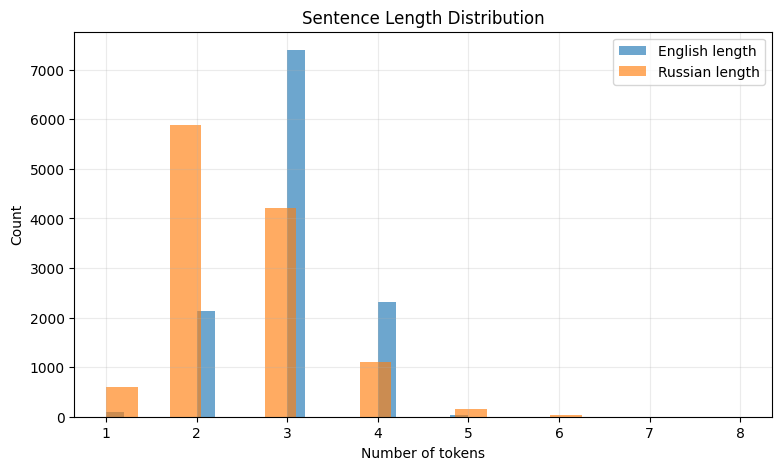

In [9]:
plt.figure(figsize=(9, 5))
plt.hist(data_table["en_len"], bins=20, alpha=0.65, label="English length")
plt.hist(data_table["ru_len"], bins=20, alpha=0.65, label="Russian length")
plt.title("Sentence Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Count")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

### Encoder, Decoder, Seq2Seq

In [10]:
class EncoderNet(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=src_vocab["<pad>"])
        self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True)

    def forward(self, source_ids):
        embedded = self.embedding(source_ids)
        outputs, (hidden, cell) = self.rnn(embedded)
        return outputs, hidden, cell


class DecoderNet(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=tgt_vocab["<pad>"])
        self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.classifier = nn.Linear(hid_dim, vocab_size)

    def forward(self, current_token, hidden, cell):
        current_token = current_token.unsqueeze(1)
        embedded = self.embedding(current_token)
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        logits = self.classifier(output.squeeze(1))
        return logits, hidden, cell


class TranslatorNet(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, source_ids, target_ids, teacher_force=0.5):
        batch_size = source_ids.size(0)
        target_len = target_ids.size(1)
        vocab_size = self.decoder.classifier.out_features

        all_logits = torch.zeros(batch_size, target_len, vocab_size, device=source_ids.device)

        _, hidden, cell = self.encoder(source_ids)

        next_token = target_ids[:, 0]   # <sos>

        for step in range(1, target_len):
            logits, hidden, cell = self.decoder(next_token, hidden, cell)
            all_logits[:, step, :] = logits

            teacher_pick = random.random() < teacher_force
            guessed_token = logits.argmax(dim=1)
            next_token = target_ids[:, step] if teacher_pick else guessed_token

        return all_logits

In [11]:
EMB_SIZE = 128
HID_SIZE = 256
LEARNING_RATE = 0.001

encoder_side = EncoderNet(len(src_vocab), EMB_SIZE, HID_SIZE)
decoder_side = DecoderNet(len(tgt_vocab), EMB_SIZE, HID_SIZE)

model = TranslatorNet(encoder_side, decoder_side).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss(ignore_index=tgt_vocab["<pad>"])

print(model)

TranslatorNet(
  (encoder): EncoderNet(
    (embedding): Embedding(1958, 128, padding_idx=0)
    (rnn): LSTM(128, 256, batch_first=True)
  )
  (decoder): DecoderNet(
    (embedding): Embedding(5261, 128, padding_idx=0)
    (rnn): LSTM(128, 256, batch_first=True)
    (classifier): Linear(in_features=256, out_features=5261, bias=True)
  )
)


### Training and Validation Functions

In [12]:
def run_train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    running_loss = 0.0

    for source_ids, target_ids in loader:
        source_ids = source_ids.to(device)
        target_ids = target_ids.to(device)

        optimizer.zero_grad()

        logits = model(source_ids, target_ids, teacher_force=0.5)

        logits = logits[:, 1:, :].reshape(-1, logits.size(-1))
        gold = target_ids[:, 1:].reshape(-1)

        loss = loss_fn(logits, gold)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


def run_valid_epoch(model, loader, loss_fn):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for source_ids, target_ids in loader:
            source_ids = source_ids.to(device)
            target_ids = target_ids.to(device)

            logits = model(source_ids, target_ids, teacher_force=0.0)

            logits = logits[:, 1:, :].reshape(-1, logits.size(-1))
            gold = target_ids[:, 1:].reshape(-1)

            loss = loss_fn(logits, gold)
            running_loss += loss.item()

    return running_loss / len(loader)

### Train the Model

In [13]:
EPOCHS = 8

train_curve = []
val_curve = []
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss = run_train_epoch(model, train_loader, optimizer, loss_fn)
    val_loss = run_valid_epoch(model, val_loader, loss_fn)

    train_curve.append(train_loss)
    val_curve.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_seq2seq_translation.pt")

    spent = time.time() - start_time
    print(
        f"Epoch {epoch+1:02d} | "
        f"train loss = {train_loss:.4f} | "
        f"val loss = {val_loss:.4f} | "
        f"time = {spent:.1f}s"
    )

Epoch 01 | train loss = 4.8528 | val loss = 4.2744 | time = 36.5s
Epoch 02 | train loss = 3.6790 | val loss = 3.8439 | time = 35.8s
Epoch 03 | train loss = 3.0927 | val loss = 3.5395 | time = 35.0s
Epoch 04 | train loss = 2.6087 | val loss = 3.3082 | time = 39.4s
Epoch 05 | train loss = 2.1814 | val loss = 3.1273 | time = 33.9s
Epoch 06 | train loss = 1.8061 | val loss = 2.9639 | time = 34.9s
Epoch 07 | train loss = 1.4925 | val loss = 2.8645 | time = 36.6s
Epoch 08 | train loss = 1.2431 | val loss = 2.8094 | time = 34.0s


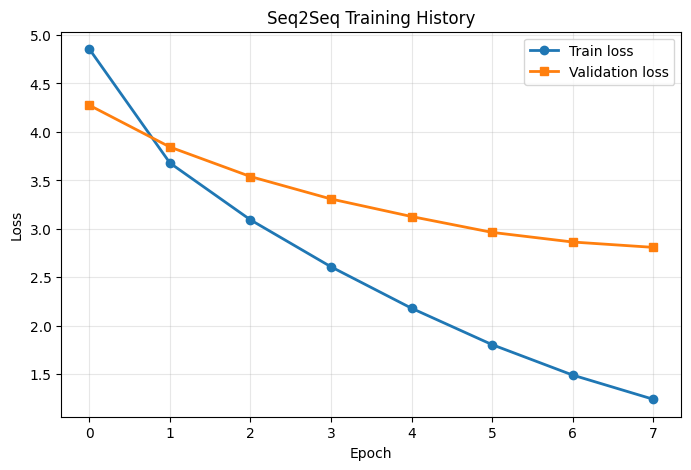

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(train_curve, marker="o", linewidth=2, label="Train loss")
plt.plot(val_curve, marker="s", linewidth=2, label="Validation loss")
plt.title("Seq2Seq Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [15]:
model.load_state_dict(torch.load("best_seq2seq_translation.pt", map_location=device))
model.eval()

def ids_to_words(id_list, id2word):
    words = []
    for idx in id_list:
        token = id2word.get(idx, "<unk>")
        if token == "<eos>":
            break
        if token not in ["<sos>", "<pad>"]:
            words.append(token)
    return words

def prepare_source(sentence):
    cleaned = normalize_text(sentence)
    tokens = cleaned.split()
    ids = [src_vocab.get(tok, src_vocab["<unk>"]) for tok in tokens]
    return tokens, ids

In [16]:
def greedy_decode(model, sentence, max_len=20):
    model.eval()

    src_tokens, src_ids = prepare_source(sentence)
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        _, hidden, cell = model.encoder(src_tensor)

    current_token = torch.tensor([tgt_vocab["<sos>"]], dtype=torch.long).to(device)
    generated = []

    for _ in range(max_len):
        with torch.no_grad():
            logits, hidden, cell = model.decoder(current_token, hidden, cell)

        next_id = logits.argmax(dim=1).item()

        if next_id == tgt_vocab["<eos>"]:
            break

        generated.append(next_id)
        current_token = torch.tensor([next_id], dtype=torch.long).to(device)

    return ids_to_words(generated, tgt_id2word)

demo_sentences = [
    "the boy opened the window",
    "i am very hungry now",
    "this is a good idea",
    "where is the cinema"
]

for text in demo_sentences:
    print("EN:", text)
    print("RU:", " ".join(greedy_decode(model, text)))
    print("-" * 50)

EN: the boy opened the window
RU: помойте машину
--------------------------------------------------
EN: i am very hungry now
RU: я сейчас
--------------------------------------------------
EN: this is a good idea
RU: это шутка
--------------------------------------------------
EN: where is the cinema
RU: где
--------------------------------------------------


### BLEU Functions From Scratch

In [17]:
def get_ngrams(tokens, n):
    if len(tokens) < n:
        return Counter()
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1))


def clipped_precision(reference, hypothesis, n):
    ref_counts = get_ngrams(reference, n)
    hyp_counts = get_ngrams(hypothesis, n)

    clipped_total = 0
    hyp_total = sum(hyp_counts.values())

    for gram, count in hyp_counts.items():
        clipped_total += min(count, ref_counts.get(gram, 0))

    if hyp_total == 0:
        return 0.0

    return clipped_total / hyp_total


def brevity_penalty(reference, hypothesis):
    ref_len = len(reference)
    hyp_len = len(hypothesis)

    if hyp_len == 0:
        return 0.0
    if hyp_len > ref_len:
        return 1.0

    return math.exp(1 - ref_len / hyp_len)


def bleu_score(reference, hypothesis, max_n=4):
    precisions = [clipped_precision(reference, hypothesis, n) for n in range(1, max_n + 1)]

    if min(precisions) == 0:
        return 0.0

    avg_log = sum(math.log(p) for p in precisions) / max_n
    bp = brevity_penalty(reference, hypothesis)

    return bp * math.exp(avg_log)


def corpus_bleu(references, hypotheses, max_n=4):
    precision_values = []

    for n in range(1, max_n + 1):
        clipped_sum = 0
        total_sum = 0

        for ref, hyp in zip(references, hypotheses):
            ref_counts = get_ngrams(ref, n)
            hyp_counts = get_ngrams(hyp, n)

            clipped_sum += sum(min(count, ref_counts.get(gram, 0)) for gram, count in hyp_counts.items())
            total_sum += sum(hyp_counts.values())

        if total_sum == 0:
            precision_values.append(0.0)
        else:
            precision_values.append(clipped_sum / total_sum)

    if min(precision_values) == 0:
        return 0.0

    total_ref_len = sum(len(ref) for ref in references)
    total_hyp_len = sum(len(hyp) for hyp in hypotheses)

    if total_hyp_len == 0:
        return 0.0

    if total_hyp_len > total_ref_len:
        bp = 1.0
    else:
        bp = math.exp(1 - total_ref_len / total_hyp_len)

    avg_log = sum(math.log(p) for p in precision_values) / max_n
    return bp * math.exp(avg_log)

In [19]:
ref_example = "the match was postponed because it was snowing".split()
hyp_example = "the match was postponed because of the snow".split()

test_bleu = bleu_score(ref_example, hyp_example, max_n=4)
print("Expected ≈ 0.516")
print("BLEU:", round(test_bleu, 6))

Expected ≈ 0.516
BLEU: 0.516973


In [20]:
def evaluate_on_validation(frame, decode_function):
    all_refs = []
    all_hyps = []

    for _, row in frame.iterrows():
        source_sentence = row["en_text"]
        reference_tokens = [tok for tok in row["ru_tokens"] if tok not in ["<sos>", "<eos>", "<pad>"]]
        hypothesis_tokens = decode_function(model, source_sentence)

        all_refs.append(reference_tokens)
        all_hyps.append(hypothesis_tokens)

    bleu1 = corpus_bleu(all_refs, all_hyps, max_n=1)
    bleu2 = corpus_bleu(all_refs, all_hyps, max_n=2)
    bleu4 = corpus_bleu(all_refs, all_hyps, max_n=4)

    return bleu1, bleu2, bleu4

full_bleu1, full_bleu2, full_bleu4 = evaluate_on_validation(val_frame, greedy_decode)

print(f"Validation BLEU-1: {full_bleu1:.4f}")
print(f"Validation BLEU-2: {full_bleu2:.4f}")
print(f"Validation BLEU-4: {full_bleu4:.4f}")

Validation BLEU-1: 0.4461
Validation BLEU-2: 0.2847
Validation BLEU-4: 0.1635


In [21]:
def beam_search(model, sentence, beam_width=5, max_len=20):
    model.eval()

    src_tokens, src_ids = prepare_source(sentence)
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        _, hidden, cell = model.encoder(src_tensor)

    beams = [([tgt_vocab["<sos>"]], 0.0, hidden, cell)]
    finished = []

    for _ in range(max_len):
        next_round = []

        for seq, score, hid, cel in beams:
            last_token = seq[-1]

            if last_token == tgt_vocab["<eos>"]:
                finished.append((seq, score))
                continue

            token_tensor = torch.tensor([last_token], dtype=torch.long).to(device)

            with torch.no_grad():
                logits, new_hid, new_cel = model.decoder(token_tensor, hid, cel)
                log_probs = F.log_softmax(logits, dim=1)

            top_log_probs, top_ids = torch.topk(log_probs, beam_width, dim=1)

            for i in range(beam_width):
                candidate_id = top_ids[0, i].item()
                candidate_score = score + top_log_probs[0, i].item()
                candidate_seq = seq + [candidate_id]

                next_round.append((
                    candidate_seq,
                    candidate_score,
                    new_hid.clone(),
                    new_cel.clone()
                ))

        if not next_round:
            break

        next_round = sorted(next_round, key=lambda x: x[1], reverse=True)
        beams = next_round[:beam_width]

    if not finished:
        finished = [(seq, score) for seq, score, _, _ in beams]

    best_seq = sorted(finished, key=lambda x: x[1], reverse=True)[0][0]
    return ids_to_words(best_seq, tgt_id2word)


def decode_beam3(model, sentence):
    return beam_search(model, sentence, beam_width=3)

def decode_beam5(model, sentence):
    return beam_search(model, sentence, beam_width=5)

def decode_beam10(model, sentence):
    return beam_search(model, sentence, beam_width=10)

In [22]:
test_lines = [
    "the boy opened the window",
    "i am very hungry now",
    "this is a good idea",
    "please show me the path"
]

for line in test_lines:
    print("EN:", line)
    print("Greedy:", " ".join(greedy_decode(model, line)))
    print("Beam-5:", " ".join(decode_beam5(model, line)))
    print("=" * 60)

EN: the boy opened the window
Greedy: помойте машину
Beam-5: помой машину
EN: i am very hungry now
Greedy: я сейчас
Beam-5: я сейчас
EN: this is a good idea
Greedy: это шутка
Beam-5: это шутка
EN: please show me the path
Greedy: покажите мне
Beam-5: покажите мне


In [23]:
def evaluate_decoder_subset(frame, decode_function, title, take_n=100):
    picked = frame.iloc[:take_n].copy().reset_index(drop=True)

    refs = []
    hyps = []

    start_time = time.time()

    for _, row in picked.iterrows():
        src_sentence = row["en_text"]
        ref_tokens = [tok for tok in row["ru_tokens"] if tok not in ["<sos>", "<eos>", "<pad>"]]
        hyp_tokens = decode_function(model, src_sentence)

        refs.append(ref_tokens)
        hyps.append(hyp_tokens)

    total_time = time.time() - start_time
    avg_time = total_time / len(picked)
    bleu4 = corpus_bleu(refs, hyps, max_n=4)

    return {
        "Method": title,
        "BLEU-4": round(bleu4, 4),
        "Avg seconds / sentence": round(avg_time, 4)
    }

comparison_rows = [
    evaluate_decoder_subset(val_frame, greedy_decode, "Greedy", take_n=100),
    evaluate_decoder_subset(val_frame, decode_beam3, "Beam width = 3", take_n=100),
    evaluate_decoder_subset(val_frame, decode_beam5, "Beam width = 5", take_n=100),
    evaluate_decoder_subset(val_frame, decode_beam10, "Beam width = 10", take_n=100),
]

comparison_table = pd.DataFrame(comparison_rows)
comparison_table

,Method,BLEU-4,Avg seconds / sentence
0,Greedy,0.0,0.0057
1,Beam width = 3,0.0,0.0236
2,Beam width = 5,0.0,0.0529
3,Beam width = 10,0.0,0.1265


In [25]:
example_rows = []

for _, row in val_frame.iloc[:120].iterrows():
    source_sentence = row["en_text"]
    reference_sentence = " ".join([tok for tok in row["ru_tokens"] if tok not in ["<sos>", "<eos>", "<pad>"]])

    greedy_sentence = " ".join(greedy_decode(model, source_sentence))
    beam_sentence = " ".join(decode_beam5(model, source_sentence))

    if greedy_sentence != beam_sentence:
        example_rows.append({
            "Source": source_sentence,
            "Greedy": greedy_sentence,
            "Beam-5": beam_sentence,
            "Reference": reference_sentence
        })

    if len(example_rows) == 5:
        break
if len(example_rows) < 5:
    for _, row in val_frame.iloc[:40].iterrows():
        source_sentence = row["en_text"]
        reference_sentence = " ".join([tok for tok in row["ru_tokens"] if tok not in ["<sos>", "<eos>", "<pad>"]])

        greedy_sentence = " ".join(greedy_decode(model, source_sentence))
        beam_sentence = " ".join(decode_beam5(model, source_sentence))

        pack = {
            "Source": source_sentence,
            "Greedy": greedy_sentence,
            "Beam-5": beam_sentence,
            "Reference": reference_sentence
        }

        if pack not in example_rows:
            example_rows.append(pack)

        if len(example_rows) == 5:
            break

examples_table = pd.DataFrame(example_rows)
examples_table

,Source,Greedy,Beam-5,Reference
0,it did happen,это сработало,сработало это,это действительно случилось
1,i was too shy,я слишком слишком,я слишком смущалась,я был слишком стеснителен
2,he got a d,он получил,он разозлился,он получил тройку
3,it s too late,слишком слишком поздно,слишком поздно,слишком поздно
4,let tom rest,пусть тому тому,пусть тому,дайте тому отдохнуть


In [26]:
for i, row in examples_table.iterrows():
    print(f"Example {i+1}")
    print("Source   :", row["Source"])
    print("Greedy   :", row["Greedy"])
    print("Beam-5   :", row["Beam-5"])
    print("Reference:", row["Reference"])
    print("-" * 80)

Example 1
Source   : it did happen
Greedy   : это сработало
Beam-5   : сработало это
Reference: это действительно случилось
--------------------------------------------------------------------------------
Example 2
Source   : i was too shy
Greedy   : я слишком слишком
Beam-5   : я слишком смущалась
Reference: я был слишком стеснителен
--------------------------------------------------------------------------------
Example 3
Source   : he got a d
Greedy   : он получил
Beam-5   : он разозлился
Reference: он получил тройку
--------------------------------------------------------------------------------
Example 4
Source   : it s too late
Greedy   : слишком слишком поздно
Beam-5   : слишком поздно
Reference: слишком поздно
--------------------------------------------------------------------------------
Example 5
Source   : let tom rest
Greedy   : пусть тому тому
Beam-5   : пусть тому
Reference: дайте тому отдохнуть
----------------------------------------------------------------------------